# Chapter 6 — Cross-model steering transport (companion notebook)

Runs one cell of the Phase 6 matrix end-to-end: Pythia-160M → GPT-2-small, sentiment, single seed (so it fits in ~3 minutes on the project 4 GB GPU). The full experimental matrix (2 cells × 4 methods × 3 coefficients × 3 seeds with bootstrap CIs) is in `experiments/run_transport.py`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

experiments_dir = Path.cwd() / "experiments"
if str(experiments_dir) not in sys.path:
    sys.path.insert(0, str(experiments_dir))

from demo import run_transport_demo  # noqa: E402
from make_figures import _fig_pipeline_diagram, _fig_demo_lift  # noqa: E402

## 1. The pipeline

Source CHaRS map (Phase 4) → cross-model GW (Phase 5) → barycentric chain → per-B-NEG-cluster transported displacement. The runtime hook soft-assigns each token to a B NEG cluster and blends the per-cluster displacements.

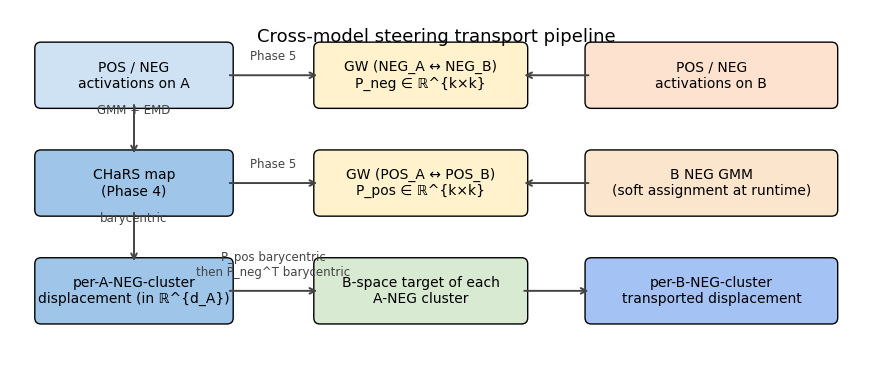

In [2]:
fig = _fig_pipeline_diagram()
plt.show()

## 2. Run the demo

Four methods are compared:
- **random** — unit-norm random vector in target space (chance floor).
- **Procrustes** — source direction rotated into target space via orthogonal Procrustes on matched centroids (classical linear-alignment baseline).
- **GW transport** — the headline method (CHaRS + cross-model GW + barycentric chain).
- **target oracle** — difference-of-means computed *directly* on target activations (upper bound, requires target-side supervision).

In [3]:
demo = run_transport_demo()
print("source:", demo.source_model_id, "layer", demo.source_layer)
print("target:", demo.target_model_id, "layer", demo.target_layer)
print("baseline off-target ppl:", demo.baseline_off_target_ppl)
print()
for method in ("random", "procrustes", "gw_transport", "target_oracle"):
    print(f"\n{method}:")
    for coef in demo.coefficients:
        sr = demo.shift_rates_by_method[method][coef]
        ppl = demo.off_target_ppl_by_method[method][coef]
        print(f"  coef={coef:.1f}  shift={sr:.0%}  off_target_ppl={ppl:.2f}")

2026-05-18T23:51:52 INFO    ot_steering.activations.datasets :: loaded sentiment dataset 'sentiment' with 50 pairs


2026-05-18T23:51:52 INFO    ot_steering.activations.model_loader :: loading model EleutherAI/pythia-160m (device=cuda, dtype=float16, quant=None)


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

2026-05-18T23:51:54 INFO    ot_steering.activations.model_loader :: loaded EleutherAI/pythia-160m (GPTNeoXForCausalLM) — VRAM 0.0 → 310.2 MB (Δ +310.2)


2026-05-18T23:51:54 INFO    ot_steering.activations.extractor :: extract: n_prompts=30 layers=[6] position=last_token batch=8


...

2026-05-18T23:52:05 INFO    ot_steering.steering.ot_steering :: fit_gmm: n_samples=30 d=768 k=4 cov=diag converged=True log-likelihood=-170.969


2026-05-18T23:52:12 INFO    ot_steering.steering.cross_model_align :: cross_model_gw: source_pts=4 target_pts=4 metric=euclidean gw_cost=0.2655


2026-05-18T23:52:15 INFO    ot_steering.steering.cross_model_align :: cross_model_gw: source_pts=4 target_pts=4 metric=euclidean gw_cost=0.2730


2026-05-18T23:52:15 INFO    ot_steering.steering.transport :: build_transport: k=4, mean ||transported_disp|| = 190.115


source: EleutherAI/pythia-160m layer 6
target: gpt2 layer 6
baseline off-target ppl: 70.01604461669922


random:
  coef=1.0  shift=5%  off_target_ppl=70.33
  coef=3.0  shift=5%  off_target_ppl=70.96
  coef=6.0  shift=0%  off_target_ppl=71.64

procrustes:
  coef=1.0  shift=5%  off_target_ppl=70.02
  coef=3.0  shift=5%  off_target_ppl=69.97
  coef=6.0  shift=10%  off_target_ppl=71.14

gw_transport:
  coef=1.0  shift=10%  off_target_ppl=69.79
  coef=3.0  shift=10%  off_target_ppl=69.88
  coef=6.0  shift=15%  off_target_ppl=70.02

target_oracle:
  coef=1.0  shift=10%  off_target_ppl=69.93
  coef=3.0  shift=15%  off_target_ppl=70.06
  coef=6.0  shift=15%  off_target_ppl=70.19


## 3. Demo-cell lift curves

Single-seed version of the chapter's headline figure. The full matrix with 95% bootstrap confidence intervals lives in `outputs/<run_id>/run_transport.json` after `python experiments/run_transport.py`.

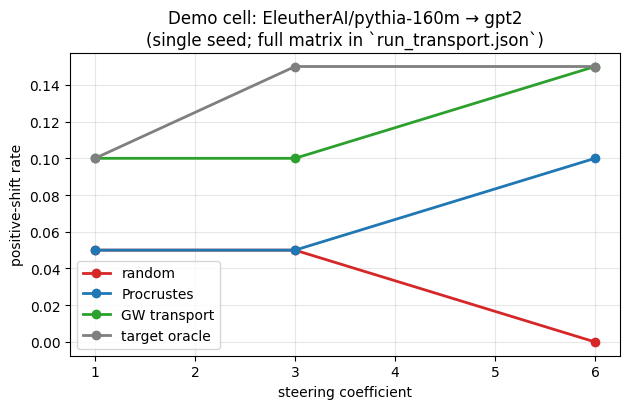

In [4]:
fig = _fig_demo_lift(demo)
plt.show()

## What we just learned

If GW transport beats the random baseline at any coefficient, the project's core hypothesis is partially vindicated: a target-side, input-conditional steering map can be built from source-side supervision plus a structural alignment, with no target-side concept labels. The relevant comparison points are (i) random (chance floor) and (ii) target oracle (the ceiling that target-supervised steering achieves). Procrustes is the classical reference for linear cross-space alignment.

The chapter discusses where this works and where it doesn't, cell by cell. Next: Phase 7 will look at the diagnostic question — does GW alignment cost predict transfer success?